# Семинар 3. Статистическая проверка качества регрессии.

### 1. Загрузим файл candidates.csv

In [4]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\koval\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
# Импортируем библиотеку pandas
import pandas as pd

# Указываем путь к файлу candidates.csv
file_path = r"C:\Users\koval\OneDrive\Desktop\МИФИ\ML\практика\candidates.csv"

# Загружаем данные из CSV-файла
data = pd.read_csv(file_path)

# Выводим данные на экран
data

,Код претендента;Рейтинг университета окончания;Средний балл диплома;Опыт работы (лет);Возраст;Рейтинг университета диплома;Баллы за сертификаты;Желаемая заработная плата;Итоговая зарплата от компании
1001;82;3,22;10;33;84;89;237000;237000
1002;4;3,19;3;29;16;0;155000;155000
1003;70;3,84;6;30;70;74;212000;197000
1004;98;3,67;2;24;97;64;140000;130000
1005;94;3,92;2;27;99;66;146000;136000
...,...
1796;67;4,43;11;34;67;72;347000;294000
1797;62;4,75;2;25;56;45;149000;149000
1798;51;4,75;15;41;37;22;434000;371000
1799;81;3,46;2;27;84;71;149000;139000


In [7]:
# Загружаем CSV-файл, указывая разделитель ;
data = pd.read_csv(file_path, sep=";")

# Выводим таблицу
data

,Код претендента,Рейтинг университета окончания,Средний балл диплома,Опыт работы (лет),Возраст,Рейтинг университета диплома,Баллы за сертификаты,Желаемая заработная плата,Итоговая зарплата от компании
0,1001,82,"3,22",10,33,84,89,237000,237000
1,1002,4,"3,19",3,29,16,0,155000,155000
2,1003,70,"3,84",6,30,70,74,212000,197000
3,1004,98,"3,67",2,24,97,64,140000,130000
4,1005,94,"3,92",2,27,99,66,146000,136000
...,...,...,...,...,...,...,...,...,...
795,1796,67,"4,43",11,34,67,72,347000,294000
796,1797,62,"4,75",2,25,56,45,149000,149000
797,1798,51,"4,75",15,41,37,22,434000,371000
798,1799,81,"3,46",2,27,84,71,149000,139000


### 2. Матрица характеристик X и столбец ответов y

In [8]:
# Создаем матрицу характеристик X, удаляя код претендента и итоговую зарплату
X = data.drop(columns=["Код претендента", "Итоговая зарплата от компании"])

# Преобразуем средний балл диплома из строки вида "3,11"
# в вещественное число 3.11
X["Средний балл диплома"] = (
    X["Средний балл диплома"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

# Проверяем типы всех характеристик
print(X.dtypes)

# Создаем столбец целевой переменной y
y = data["Итоговая зарплата от компании"]

# Выводим матрицу характеристик X
print("Матрица характеристик X:")
display(X)

# Выводим целевую переменную y
print("Целевая переменная y:")
display(y)

Рейтинг университета окончания      int64
Средний балл диплома              float64
Опыт работы (лет)                   int64
Возраст                             int64
Рейтинг университета диплома        int64
Баллы за сертификаты                int64
Желаемая заработная плата           int64
dtype: object
Матрица характеристик X:


,Рейтинг университета окончания,Средний балл диплома,Опыт работы (лет),Возраст,Рейтинг университета диплома,Баллы за сертификаты,Желаемая заработная плата
0,82,3.22,10,33,84,89,237000
1,4,3.19,3,29,16,0,155000
2,70,3.84,6,30,70,74,212000
3,98,3.67,2,24,97,64,140000
4,94,3.92,2,27,99,66,146000
...,...,...,...,...,...,...,...
795,67,4.43,11,34,67,72,347000
796,62,4.75,2,25,56,45,149000
797,51,4.75,15,41,37,22,434000
798,81,3.46,2,27,84,71,149000


Целевая переменная y:


0      237000
1      155000
2      197000
3      130000
4      136000
        ...  
795    294000
796    149000
797    371000
798    139000
799    183000
Name: Итоговая зарплата от компании, Length: 800, dtype: int64

### 3. Используя SAG, строим модель линейной регрессии

In [9]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\koval\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Разделим выборку на train, val, test

In [10]:
from sklearn.model_selection import train_test_split

# Делим данные на 70% train и 30% для val + test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Оставшиеся 30% делим пополам
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

# Проверяем размеры
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (560, 7)
X_val: (120, 7)
X_test: (120, 7)


Стандартизируем характеристики

In [11]:
from sklearn.preprocessing import StandardScaler

# Создаем стандартизатор
scaler = StandardScaler()

# Параметры стандартизации вычисляем ТОЛЬКО по train
X_train_scaled = scaler.fit_transform(X_train)

# К validation применяем параметры, полученные по train
X_val_scaled = scaler.transform(X_val)

# К test применяем те же параметры
X_test_scaled = scaler.transform(X_test)

# Проверяем размеры
print(X_train_scaled.shape)
print(X_val_scaled.shape)
print(X_test_scaled.shape)

(560, 7)
(120, 7)
(120, 7)


Реализуем SAG

In [12]:
# Импортируем numpy
import numpy as np


# Создаем функцию SAG
def sag_regression(X, y, learning_rate=0.001, epochs=500, random_state=42):

    # Преобразуем X в numpy-массив
    X = np.asarray(X, dtype=float)

    # Преобразуем y в numpy-массив
    y = np.asarray(y, dtype=float)

    # Количество объектов
    n = X.shape[0]

    # Количество характеристик
    k = X.shape[1]

    # Добавляем столбец единиц для свободного коэффициента b0
    X_with_intercept = np.column_stack((np.ones(n), X))

    # Создаем начальные коэффициенты:
    # b0, b1, ..., bk
    weights = np.zeros(k + 1)

    # Здесь будем хранить последний градиент
    # для каждого объекта тренировочной выборки
    gradients = np.zeros((n, k + 1))

    # Сумма всех сохраненных градиентов
    gradient_sum = np.zeros(k + 1)

    # Создаем генератор случайных чисел
    rng = np.random.default_rng(random_state)

    # Запускаем обучение
    for epoch in range(epochs):

        # Перемешиваем номера объектов
        indices = rng.permutation(n)

        # Последовательно рассматриваем объекты
        for i in indices:

            # Вычисляем предсказание для i-го объекта
            y_pred = X_with_intercept[i] @ weights

            # Вычисляем ошибку
            error = y_pred - y[i]

            # Вычисляем новый градиент для i-го объекта
            new_gradient = error * X_with_intercept[i]

            # Получаем старый сохраненный градиент этого объекта
            old_gradient = gradients[i].copy()

            # Заменяем старый градиент новым
            gradients[i] = new_gradient

            # Обновляем сумму сохраненных градиентов
            gradient_sum += new_gradient - old_gradient

            # Находим средний сохраненный градиент
            average_gradient = gradient_sum / n

            # Обновляем коэффициенты модели
            weights -= learning_rate * average_gradient

    # Возвращаем найденные коэффициенты
    return weights

Обучаем модель

In [13]:
# Обучаем линейную регрессию методом SAG
weights = sag_regression(
    X_train_scaled,
    y_train,
    learning_rate=0.001,
    epochs=500,
    random_state=42
)

# Выводим найденные коэффициенты
print(weights)

[228344.6428236   -4218.91247277   6748.29446976  43292.58853641
   1073.18570929  -5808.66826642   7076.16635697  25967.55727075]


Уравнение модели

In [14]:
# Получаем свободный коэффициент для стандартизированных данных
b0_scaled = weights[0]

# Получаем коэффициенты при характеристиках
b_scaled = weights[1:]

# Возвращаем коэффициенты к исходному масштабу X
b = b_scaled / scaler.scale_

# Пересчитываем свободный коэффициент
b0 = b0_scaled - np.sum(
    b_scaled * scaler.mean_ / scaler.scale_
)

# Выводим коэффициенты модели
print("Коэффициенты модели:")

print("b0 =", b0)

for feature, coefficient in zip(X.columns, b):
    print(feature, ":", coefficient)


# Формируем строку с уравнением модели
equation = f"ŷ = {b0:.4f}"

for feature, coefficient in zip(X.columns, b):

    # Если коэффициент положительный
    if coefficient >= 0:
        equation += f" + {coefficient:.4f} * {feature}"

    # Если коэффициент отрицательный
    else:
        equation += f" - {abs(coefficient):.4f} * {feature}"


# Выводим итоговое уравнение
print("\nИтоговое уравнение модели:")
print(equation)

Коэффициенты модели:
b0 = 32112.199511414598
Рейтинг университета окончания : -147.28476094257883
Средний балл диплома : 11654.268834007262
Опыт работы (лет) : 9553.849009356723
Возраст : 230.1611341573023
Рейтинг университета диплома : -199.46326435246368
Баллы за сертификаты : 230.55614522277978
Желаемая заработная плата : 0.32381117019138134

Итоговое уравнение модели:
ŷ = 32112.1995 - 147.2848 * Рейтинг университета окончания + 11654.2688 * Средний балл диплома + 9553.8490 * Опыт работы (лет) + 230.1611 * Возраст - 199.4633 * Рейтинг университета диплома + 230.5561 * Баллы за сертификаты + 0.3238 * Желаемая заработная плата


### 4. Проверяем веса на знасимость

Пусть построена модель линейной регрессии:

$$
\hat{y} = b_0 + b_1x_1 + b_2x_2 + \ldots + b_kx_k.
$$

Необходимо проверить, является ли каждый коэффициент $b_i$ статистически значимым.

### Шаг 1. Формулируем гипотезы

Для каждого коэффициента $b_i$ проверяются две гипотезы:

$$
H_0: b_i = 0,
$$

$$
H_1: b_i \neq 0.
$$

Если принимается $H_0$, то характеристика $x_i$ не является значимой для модели.

Если принимается $H_1$, то характеристика $x_i$ является значимой для модели.


### Шаг 2. Вычисляем остаточную дисперсию

Сначала для каждого наблюдения вычисляем предсказание модели:

$$
\hat{y}_i =
b_0 + b_1x_{i1} + b_2x_{i2} + \ldots + b_kx_{ik}.
$$

Затем вычисляем остаточную дисперсию:

$$
s_e^2 =
\frac{1}{n-k-1}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2,
$$

где:

- $n$ — количество наблюдений;
- $k$ — количество характеристик;
- $y_i$ — настоящее значение целевой переменной;
- $\hat{y}_i$ — предсказанное моделью значение.


### Шаг 3. Строим ковариационную матрицу коэффициентов

Создаем матрицу признаков $X$, включающую столбец единиц для свободного коэффициента $b_0$:

$$
X =
\begin{pmatrix}
1 & x_{11} & \ldots & x_{1k}\\
1 & x_{21} & \ldots & x_{2k}\\
\vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & \ldots & x_{nk}
\end{pmatrix}.
$$

Ковариационная матрица коэффициентов вычисляется по формуле:

$$
C = s_e^2(X^TX)^{-1}.
$$


### Шаг 4. Находим стандартную ошибку каждого коэффициента

Для каждого коэффициента $b_i$ берем соответствующий диагональный элемент $c_{ii}$ матрицы $C$:

$$
S(b_i)=\sqrt{c_{ii}}.
$$


### Шаг 5. Вычисляем t-статистику

Для каждого коэффициента вычисляем:

$$
t_i =
\frac{b_i}{S(b_i)}.
$$


### Шаг 6. Находим критические значения распределения Стьюдента

Задаем уровень доверия:

$$
1-\alpha.
$$

Обычно используется:

$$
1-\alpha=0.95,
$$

следовательно,

$$
\alpha=0.05.
$$

Число степеней свободы:

$$
\nu=n-k-1.
$$

Находим квантили распределения Стьюдента:

$$
t_{\alpha/2}
\quad\text{и}\quad
t_{1-\alpha/2}.
$$


### Шаг 7. Проверяем значимость коэффициента

Если

$$
t_i \in
[t_{\alpha/2},\,t_{1-\alpha/2}],
$$

то принимаем гипотезу

$$
H_0:b_i=0.
$$

Следовательно, коэффициент $b_i$ статистически незначим, а характеристика $x_i$ не является важной для модели.

Если

$$
t_i \notin
[t_{\alpha/2},\,t_{1-\alpha/2}],
$$

то принимаем гипотезу

$$
H_1:b_i\neq0.
$$

Следовательно, коэффициент $b_i$ статистически значим, а характеристика $x_i$ является важной для модели.

In [15]:
# Импортируем numpy
import numpy as np

# Импортируем распределение Стьюдента
from scipy.stats import t


# ============================================================
# 1. Подготавливаем данные
# ============================================================

# Преобразуем y_train в numpy-массив
y_train_array = np.asarray(y_train, dtype=float)

# Определяем количество наблюдений n
n = X_train_scaled.shape[0]

# Определяем количество характеристик k
k = X_train_scaled.shape[1]

# Добавляем столбец единиц для свободного коэффициента b0
X_design = np.column_stack([
    np.ones(n),
    X_train_scaled
])


# ============================================================
# 2. Вычисляем предсказания модели
# ============================================================

# Вычисляем предсказания по формуле:
# y_hat = X * b
y_pred = X_design @ weights


# ============================================================
# 3. Вычисляем остаточную дисперсию
# ============================================================

# Вычисляем остатки:
# e_i = y_i - y_hat_i
errors = y_train_array - y_pred

# Вычисляем сумму квадратов остатков
SSE = np.sum(errors ** 2)

# Вычисляем число степеней свободы
df = n - k - 1

# Вычисляем остаточную дисперсию:
# s_e^2 = SSE / (n - k - 1)
s_e_squared = SSE / df


# ============================================================
# 4. Вычисляем ковариационную матрицу коэффициентов
# ============================================================

# Вычисляем:
# C = s_e^2 * (X^T X)^(-1)
C = s_e_squared * np.linalg.inv(
    X_design.T @ X_design
)


# ============================================================
# 5. Вычисляем стандартные ошибки коэффициентов
# ============================================================

# Берем диагональные элементы матрицы C
diagonal = np.diag(C)

# Вычисляем:
# S(b_i) = sqrt(c_ii)
standard_errors = np.sqrt(diagonal)


# ============================================================
# 6. Вычисляем t-статистики
# ============================================================

# Для каждого коэффициента вычисляем:
# t_i = b_i / S(b_i)
t_statistics = weights / standard_errors


# ============================================================
# 7. Находим критические значения распределения Стьюдента
# ============================================================

# Задаем уровень значимости
alpha = 0.05

# Находим левую границу
t_left = t.ppf(alpha / 2, df)

# Находим правую границу
t_right = t.ppf(1 - alpha / 2, df)

# Выводим критический интервал
print("Критический интервал:")
print(f"[{t_left:.4f}; {t_right:.4f}]")
print()


# ============================================================
# 8. Проверяем каждый коэффициент на значимость
# ============================================================

# Создаем названия коэффициентов
coefficient_names = ["b0"] + [
    f"b{i}" for i in range(1, k + 1)
]

# Создаем названия характеристик
feature_names = ["Свободный коэффициент"] + list(X_train.columns)


# Последовательно проверяем каждый коэффициент
for name, feature, weight, se, t_value in zip(
    coefficient_names,
    feature_names,
    weights,
    standard_errors,
    t_statistics
):

    # Выводим название коэффициента и характеристики
    print(f"{name}: {feature}")

    # Выводим значение коэффициента
    print(f"Коэффициент = {weight:.4f}")

    # Выводим стандартную ошибку
    print(f"S({name}) = {se:.4f}")

    # Выводим t-статистику
    print(f"t = {t_value:.4f}")

    # Проверяем, попала ли t-статистика в критический интервал
    if t_left <= t_value <= t_right:

        # Если попала, принимаем H0
        print("H0 принимается")

        # Коэффициент статистически незначим
        print("Коэффициент статистически НЕЗНАЧИМ")

    else:

        # Если не попала, принимаем H1
        print("H1 принимается")

        # Коэффициент статистически значим
        print("Коэффициент статистически ЗНАЧИМ")

    print()

Критический интервал:
[-1.9643; 1.9643]

b0: Свободный коэффициент
Коэффициент = 228344.6428
S(b0) = 369.0472
t = 618.7410
H1 принимается
Коэффициент статистически ЗНАЧИМ

b1: Рейтинг университета окончания
Коэффициент = -4218.9125
S(b1) = 1479.9078
t = -2.8508
H1 принимается
Коэффициент статистически ЗНАЧИМ

b2: Средний балл диплома
Коэффициент = 6748.2945
S(b2) = 403.7317
t = 16.7148
H1 принимается
Коэффициент статистически ЗНАЧИМ

b3: Опыт работы (лет)
Коэффициент = 43292.5885
S(b3) = 1664.3355
t = 26.0119
H1 принимается
Коэффициент статистически ЗНАЧИМ

b4: Возраст
Коэффициент = 1073.1857
S(b4) = 1221.8986
t = 0.8783
H0 принимается
Коэффициент статистически НЕЗНАЧИМ

b5: Рейтинг университета диплома
Коэффициент = -5808.6683
S(b5) = 1473.3738
t = -3.9424
H1 принимается
Коэффициент статистически ЗНАЧИМ

b6: Баллы за сертификаты
Коэффициент = 7076.1664
S(b6) = 405.9794
t = 17.4299
H1 принимается
Коэффициент статистически ЗНАЧИМ

b7: Желаемая заработная плата
Коэффициент = 25967.5573
S

### 5. Вес, отвечающий за возраст (b4) оказался незначимым. Переформируем все матрицы X и обучим модель повторно.

In [16]:
# Удаляем незначимую характеристику "Возраст" из X
X = X.drop(columns=["Возраст"])

# Проверяем оставшиеся характеристики
print("Характеристики модели:")
print(X.columns)

# Проверяем размер матрицы X
print("\nРазмер X:", X.shape)

Характеристики модели:
Index(['Рейтинг университета окончания', 'Средний балл диплома',
       'Опыт работы (лет)', 'Рейтинг университета диплома',
       'Баллы за сертификаты', 'Желаемая заработная плата'],
      dtype='str')

Размер X: (800, 6)


In [17]:
# Импортируем функцию разделения данных
from sklearn.model_selection import train_test_split

# Делим данные:
# 70% — тренировочная выборка
# 30% — временная выборка для validation и test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Делим оставшиеся 30% пополам:
# 15% — validation
# 15% — test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42
)

# Выводим размеры полученных матриц
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print()

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (560, 6)
X_val: (120, 6)
X_test: (120, 6)

y_train: (560,)
y_val: (120,)
y_test: (120,)


In [25]:
%pip install matplotlib

     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     --------------- ------------------------ 30.7/80.3 kB ? eta -:--:--
     ----------------------------- -------- 61.4/80.3 kB 812.7 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 kB 812.7 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 kB 812.7 kB/s eta 0:00:01
     --------------------------------- ---- 71.7/80.3 kB 302.7 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 280.1 kB/s eta 0:00:00
     ---------------------------------------- 0.0/132.6 kB ? eta -:--:--
     ----------------------------- -------- 102.4/132.6 kB 5.8 MB/s eta 0:00:01
     ----------------------------------- -- 122.9/132.6 kB 1.2 MB/s eta 0:00:01
     ------------------------------------ 132.6/132.6 kB 979.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.3 MB 6.4 MB/s eta 0:00:


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\koval\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


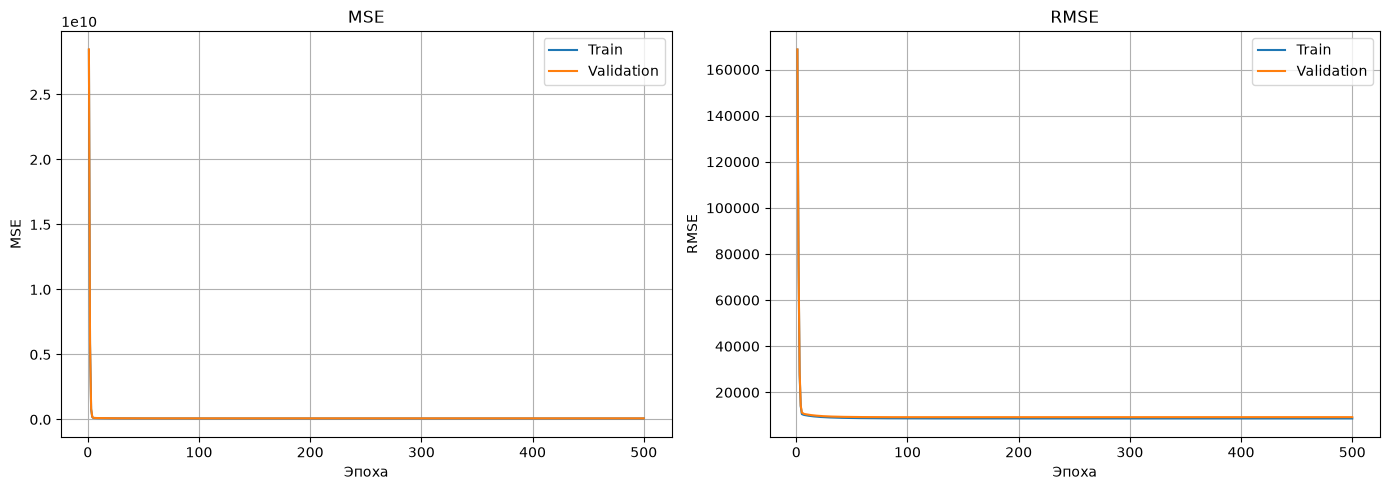

Новые веса модели:
[228344.6428236   -4218.91247277   6748.29446976  43292.58853641
   1073.18570929  -5808.66826642   7076.16635697  25967.55727075]

Итоговые ошибки:
Train MSE: 75180104.4518
Validation MSE: 85756602.2836
Train RMSE: 8670.6461
Validation RMSE: 9260.4861


In [26]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Реализуем SAG с сохранением истории ошибок
# ============================================================

def sag_regression(X, y, X_val, y_val,
                   learning_rate=0.001,
                   epochs=500,
                   random_state=42):

    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    X_val = np.asarray(X_val, dtype=float)
    y_val = np.asarray(y_val, dtype=float)

    n, k = X.shape

    # Добавляем столбец единиц
    X_train_design = np.column_stack([np.ones(n), X])
    X_val_design = np.column_stack([np.ones(len(X_val)), X_val])

    # Начальные веса
    weights = np.zeros(k + 1)

    # Память градиентов SAG
    gradients = np.zeros((n, k + 1))
    gradient_sum = np.zeros(k + 1)

    rng = np.random.default_rng(random_state)

    # История ошибок
    mse_train = []
    mse_val = []
    rmse_train = []
    rmse_val = []

    # Обучение
    for epoch in range(epochs):

        indices = rng.permutation(n)

        for i in indices:

            # Предсказание для одного объекта
            y_pred = X_train_design[i] @ weights

            # Ошибка
            error = y_pred - y[i]

            # Новый градиент
            new_gradient = error * X_train_design[i]

            # Обновляем память градиентов
            gradient_sum += new_gradient - gradients[i]
            gradients[i] = new_gradient

            # Обновляем веса методом SAG
            weights -= learning_rate * gradient_sum / n

        # Предсказания на тренировочной выборке
        y_pred_train = X_train_design @ weights

        # Предсказания на валидационной выборке
        y_pred_val = X_val_design @ weights

        # Вычисляем MSE
        train_mse = np.mean((y - y_pred_train) ** 2)
        val_mse = np.mean((y_val - y_pred_val) ** 2)

        # Сохраняем MSE
        mse_train.append(train_mse)
        mse_val.append(val_mse)

        # Сохраняем RMSE
        rmse_train.append(np.sqrt(train_mse))
        rmse_val.append(np.sqrt(val_mse))

    return weights, mse_train, mse_val, rmse_train, rmse_val


# ============================================================
# 2. Обучаем модель без характеристики "Возраст"
# ============================================================

weights, mse_train, mse_val, rmse_train, rmse_val = sag_regression(
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    learning_rate=0.001,
    epochs=500,
    random_state=42
)


# ============================================================
# 3. Строим графики MSE и RMSE
# ============================================================

epochs_range = range(1, 501)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График MSE
axes[0].plot(epochs_range, mse_train, label="Train")
axes[0].plot(epochs_range, mse_val, label="Validation")

axes[0].set_title("MSE")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[0].grid(True)

# График RMSE
axes[1].plot(epochs_range, rmse_train, label="Train")
axes[1].plot(epochs_range, rmse_val, label="Validation")

axes[1].set_title("RMSE")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("RMSE")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


# ============================================================
# 4. Выводим итоговые результаты
# ============================================================

print("Новые веса модели:")
print(weights)

print("\nИтоговые ошибки:")

print(f"Train MSE: {mse_train[-1]:.4f}")
print(f"Validation MSE: {mse_val[-1]:.4f}")

print(f"Train RMSE: {rmse_train[-1]:.4f}")
print(f"Validation RMSE: {rmse_val[-1]:.4f}")

### 6. Проверим полученную модель на значимость

Пусть построена модель линейной регрессии:

$$
\hat{y} = b_0 + b_1x_1 + b_2x_2 + \ldots + b_kx_k.
$$

Необходимо проверить, является ли модель в целом статистически значимой.

### Шаг 1. Формулируем гипотезы

Нулевая гипотеза:

$$
H_0: b_1 = b_2 = \ldots = b_k = 0.
$$

Она означает, что все коэффициенты при характеристиках равны нулю и модель статистически незначима.

Альтернативная гипотеза:

$$
H_1: b_1^2 + b_2^2 + \ldots + b_k^2 > 0.
$$

Она означает, что хотя бы один коэффициент при характеристике отличен от нуля и модель статистически значима.


### Шаг 2. Вычисляем предсказания модели

Для каждого наблюдения вычисляем:

$$
\hat{y}_i =
b_0 + b_1x_{i1} + b_2x_{i2} + \ldots + b_kx_{ik}.
$$


### Шаг 3. Вычисляем коэффициент детерминации $R^2$

Сначала находим среднее значение целевой переменной:

$$
\bar{y} =
\frac{1}{n}
\sum_{i=1}^{n} y_i.
$$

Затем вычисляем коэффициент детерминации:

$$
R^2 =
1 -
\frac{
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
}{
\sum_{i=1}^{n}(y_i-\bar{y})^2
}.
$$

где:

- $n$ — количество наблюдений;
- $k$ — количество характеристик;
- $y_i$ — настоящее значение целевой переменной;
- $\hat{y}_i$ — предсказанное моделью значение;
- $\bar{y}$ — среднее значение целевой переменной.


### Шаг 4. Вычисляем F-статистику

F-статистика вычисляется по формуле:

$$
F =
\frac{
\frac{R^2}{k}
}{
\frac{1-R^2}{n-k-1}
}.
$$


### Шаг 5. Выбираем уровень значимости

Задаем уровень доверия:

$$
1-\alpha.
$$

Обычно используется:

$$
1-\alpha = 0.95,
$$

следовательно,

$$
\alpha = 0.05.
$$


### Шаг 6. Находим критическое значение критерия Фишера

Находим квантиль распределения Фишера:

$$
F_{1-\alpha}.
$$

Для него используются степени свободы:

$$
\nu_1 = k,
$$

$$
\nu_2 = n-k-1.
$$


### Шаг 7. Проверяем статистическую значимость модели

Если

$$
F \leq F_{1-\alpha},
$$

то принимаем гипотезу

$$
H_0.
$$

Следовательно, модель статистически незначима.

Если

$$
F > F_{1-\alpha},
$$

то принимаем гипотезу

$$
H_1.
$$

Следовательно, модель статистически значима.

In [19]:
# Импортируем numpy
import numpy as np

# Импортируем распределение Фишера
from scipy.stats import f


# ============================================================
# 1. Подготавливаем валидационную выборку
# ============================================================

# Преобразуем y_val в numpy-массив
y_val_array = np.asarray(y_val, dtype=float)

# Определяем количество наблюдений n
n = X_val_scaled.shape[0]

# Определяем количество характеристик k
k = X_val_scaled.shape[1]

# Добавляем столбец единиц для свободного коэффициента b0
X_val_design = np.column_stack([
    np.ones(n),
    X_val_scaled
])


# ============================================================
# 2. Вычисляем предсказания модели
# ============================================================

# Вычисляем предсказания:
# y_hat = X * b
y_pred_val = X_val_design @ weights


# ============================================================
# 3. Вычисляем среднее значение y
# ============================================================

# Находим среднее значение целевой переменной
y_mean = np.mean(y_val_array)


# ============================================================
# 4. Вычисляем коэффициент детерминации R^2
# ============================================================

# Вычисляем сумму квадратов ошибок модели
SSE = np.sum(
    (y_val_array - y_pred_val) ** 2
)

# Вычисляем общую сумму квадратов отклонений от среднего
SST = np.sum(
    (y_val_array - y_mean) ** 2
)

# Вычисляем коэффициент детерминации
R_squared = 1 - SSE / SST


# ============================================================
# 5. Вычисляем F-статистику
# ============================================================

# Вычисляем F по формуле из лекции:
#
#          R^2 / k
# F = -------------------
#      (1 - R^2)/(n-k-1)

F_statistic = (R_squared / k) / (
    (1 - R_squared) / (n - k - 1)
)


# ============================================================
# 6. Находим критическое значение распределения Фишера
# ============================================================

# Задаем уровень значимости
alpha = 0.05

# Первая степень свободы
df1 = k

# Вторая степень свободы
df2 = n - k - 1

# Находим квантиль F_(1-alpha)
F_critical = f.ppf(
    1 - alpha,
    df1,
    df2
)


# ============================================================
# 7. Выводим результаты
# ============================================================

print("Количество наблюдений n =", n)
print("Количество характеристик k =", k)

print()

print("R² =", R_squared)
print("F =", F_statistic)
print("F критическое =", F_critical)

print()


# ============================================================
# 8. Проверяем значимость модели
# ============================================================

if F_statistic <= F_critical:

    print("F <= F критического")
    print("Принимаем H0.")
    print("Модель статистически НЕЗНАЧИМА.")

else:

    print("F > F критического")
    print("Принимаем H1.")
    print("Модель статистически ЗНАЧИМА.")

Количество наблюдений n = 120
Количество характеристик k = 7

R² = 0.9801424789192575
F = 789.7400485661109
F критическое = 2.092380833449398

F > F критического
Принимаем H1.
Модель статистически ЗНАЧИМА.


### 7. Вычисляем парный коэффициент корреляции

Парный коэффициент корреляции между характеристикой $x$ и целевой переменной $y$ вычисляется по формуле:

$$
r_{x,y}
=
\frac{
\frac{1}{n}\displaystyle\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})
}{
\sigma_x \sigma_y
}.
$$

где:

$$
\bar{x}=\frac{1}{n}\sum_{i=1}^{n}x_i,
\qquad
\bar{y}=\frac{1}{n}\sum_{i=1}^{n}y_i,
$$

а среднеквадратические отклонения вычисляются как:

$$
\sigma_x=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}(x_i-\bar{x})^2
},
$$

$$
\sigma_y=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}(y_i-\bar{y})^2
}.
$$

Чем больше $|r_{x,y}|$, тем сильнее влияние характеристики $x$ на $y$.

Если $r_{x,y}$ близок к нулю, влияние характеристики $x$ на $y$ слабее.

In [20]:
# Импортируем numpy
import numpy as np


# Перебираем все характеристики матрицы X
for feature in X.columns:

    # Получаем значения текущей характеристики
    x = X[feature].to_numpy(dtype=float)

    # Получаем значения целевой переменной
    y_array = y.to_numpy(dtype=float)

    # Вычисляем среднее значение характеристики
    x_mean = np.mean(x)

    # Вычисляем среднее значение y
    y_mean = np.mean(y_array)

    # Вычисляем стандартное отклонение характеристики
    sigma_x = np.sqrt(
        np.mean((x - x_mean) ** 2)
    )

    # Вычисляем стандартное отклонение y
    sigma_y = np.sqrt(
        np.mean((y_array - y_mean) ** 2)
    )

    # Вычисляем числитель коэффициента корреляции
    numerator = np.mean(
        (x - x_mean) * (y_array - y_mean)
    )

    # Вычисляем парный коэффициент корреляции
    r = numerator / (sigma_x * sigma_y)

    # Выводим результат
    print(f"{feature}: {r:.4f}")

Рейтинг университета окончания: -0.2725
Средний балл диплома: 0.1372
Опыт работы (лет): 0.9418
Рейтинг университета диплома: -0.2584
Баллы за сертификаты: 0.1714
Желаемая заработная плата: 0.9738


### 8. Вычисляем коэффициент детерминации

Коэффициент детерминации вычисляется по формуле:

$$
R^2 =
1 -
\frac{
\displaystyle\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
}{
\displaystyle\sum_{i=1}^{n}(y_i-\bar{y})^2
}.
$$

где:

- $y_i$ — реальное значение целевой переменной;
- $\hat{y}_i$ — предсказанное моделью значение;
- $\bar{y}$ — среднее значение целевой переменной;
- $n$ — количество наблюдений.

Среднее значение целевой переменной:

$$
\bar{y} =
\frac{1}{n}
\sum_{i=1}^{n}y_i.
$$

Если $R^2$ близок к $0$, линия модели практически не отличается от линии среднего значения $\bar{y}$.

Если $R^2$ стремится к $1$, предсказания модели близки к реальным значениям, то есть модель хорошо описывает данные.

In [21]:
# Преобразуем y_val в numpy-массив
y_val_array = np.asarray(y_val, dtype=float)

# Добавляем столбец единиц для свободного коэффициента b0
X_val_design = np.column_stack([
    np.ones(X_val_scaled.shape[0]),
    X_val_scaled
])

# Вычисляем предсказания модели
y_pred_val = X_val_design @ weights

# Вычисляем среднее значение y
y_mean = np.mean(y_val_array)

# Вычисляем сумму квадратов ошибок модели
SSE = np.sum(
    (y_val_array - y_pred_val) ** 2
)

# Вычисляем сумму квадратов отклонений y от среднего
SST = np.sum(
    (y_val_array - y_mean) ** 2
)

# Вычисляем коэффициент детерминации
R2 = 1 - SSE / SST

# Выводим R²
print("R² =", R2)

R² = 0.9801424789192575


Полученный коэффициент говорит о высоком качестве модели: предсказанные значения очень близки к реальным ответам.

### 9. Реализуем LOOCV для проверки работы модели на тестовых данных

Пусть имеется выборка из $n$ наблюдений.

### Алгоритм LOOCV

Для каждого наблюдения $i=1,\ldots,n$ выполняем следующие действия:

1. Выбираем одно наблюдение $i$ в качестве тестового.

2. Оставшиеся $n-1$ наблюдений используем в качестве тренировочной выборки.

3. Строим модель линейной регрессии на тренировочной выборке из $n-1$ наблюдений.

4. С помощью построенной модели получаем предсказание $\hat{y}_i$ для исключенного наблюдения.

5. Вычисляем ошибку предсказания:

$$
Error_i = y_i-\hat{y}_i.
$$

6. Повторяем эти действия для каждого из $n$ наблюдений.

После этого вычисляем итоговую ошибку LOOCV:

$$
LOOCV =
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
Error_i^2
}.
$$

### Интерпретация

- относительно небольшое значение $LOOCV$ означает, что модель хорошо обобщает данные;
- относительно большое значение $LOOCV$ означает, что модель плохо работает на новых данных и ее следует изменить.

In [22]:
# Импортируем numpy
import numpy as np

# Импортируем линейную регрессию
from sklearn.linear_model import LinearRegression

# Импортируем LOOCV и функцию кросс-валидации
from sklearn.model_selection import LeaveOneOut, cross_val_score

# Импортируем Pipeline
from sklearn.pipeline import make_pipeline

# Импортируем стандартизацию
from sklearn.preprocessing import StandardScaler


# Создаем линейную модель со стандартизацией
model_loocv = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

# Создаем LOOCV
loocv = LeaveOneOut()

# Выполняем LOOCV на тренировочной выборке
# neg_mean_squared_error возвращает отрицательные квадраты ошибок
scores = cross_val_score(
    model_loocv,
    X_train,
    y_train,
    cv=loocv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

# Получаем квадраты ошибок
squared_errors = -scores

# Вычисляем LOOCV по формуле из лекции
LOOCV = np.sqrt(
    np.mean(squared_errors)
)

# Выводим результат
print("LOOCV =", LOOCV)

LOOCV = 8800.201386417926


Полученная ошибка относительно мала. Поэтому модель хорошо предскажет ответы на новых тестовых данных.

### 10. Тестируем нашу модель

In [23]:
# Импортируем numpy
import numpy as np


# ============================================================
# 1. Подготавливаем тестовую выборку
# ============================================================

# Преобразуем y_test в numpy-массив
y_test_array = np.asarray(y_test, dtype=float)

# Добавляем столбец единиц для свободного коэффициента b0
X_test_design = np.column_stack([
    np.ones(X_test_scaled.shape[0]),
    X_test_scaled
])


# ============================================================
# 2. Получаем предсказания SAG-модели
# ============================================================

# Вычисляем предсказания
y_pred_test = X_test_design @ weights


# ============================================================
# 3. Вычисляем R^2
# ============================================================

# Вычисляем среднее значение y на тестовой выборке
y_mean = np.mean(y_test_array)

# Вычисляем сумму квадратов ошибок
SSE = np.sum(
    (y_test_array - y_pred_test) ** 2
)

# Вычисляем сумму квадратов отклонений от среднего
SST = np.sum(
    (y_test_array - y_mean) ** 2
)

# Вычисляем коэффициент детерминации
R2_test = 1 - SSE / SST


# ============================================================
# 4. Вычисляем ошибку RMSE
# ============================================================

# Вычисляем ошибку каждого предсказания
errors = y_test_array - y_pred_test

# Вычисляем RMSE
RMSE_test = np.sqrt(
    np.mean(errors ** 2)
)


# ============================================================
# 5. Выводим итоговые результаты
# ============================================================

print(f"R² на тестовой выборке = {R2_test:.4f}")
print(f"RMSE на тестовой выборке = {RMSE_test:.2f}")

R² на тестовой выборке = 0.9896
RMSE на тестовой выборке = 8042.78
